In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import OneHotEncoder

import sys
sys.path.append('../..')
from mount_drive import mount_s_drive

In [2]:
mount_s_drive()

Password for ikarhul1: ········


Mounting S drive subfolder LCICM
The following files and folders have been mounted to /home/idies/workspace/SAFE/:
  PMAP TBI Cohort.docx
  Sickbay
  Flowsheet_osler_ids_txt_6.csv
  Flowsheet_osler_ids_txt_1.csv
  Flowsheet_osler_ids_txt_3.csv
  Team Amaranth
  Peter
  Nick
  Ike
  LCICM
  flowsheets
  Delirium
  Isalis
  PMAP_sepsis_data_pull_statisticsxlsx.xlsx
  ecg_preprocessed
  Flowsheet_osler_ids_txt_7.csv
  Flowsheet_osler_ids_txt_4.csv
  init.txt
  MinooEmir
  PMAP_commons_dbo_CLARITY_EAP.csv
  Databases
  Flowsheet_osler_ids_txt_5.csv
  Flowsheet_osler_ids_txt_8.csv
  Flowsheet_osler_ids_txt_2.csv
  COVID


mkdir: cannot create directory '/home/idies/workspace/SAFE/': File exists


In [3]:
myHours = 60*6

In [4]:
database_folder = '/home/idies/workspace/SAFE/'

In [5]:
def read_by_chunks(file_path,chunk_size=1e6,head='infer'):
    df_chunks = []
    num_chunks = 0
    
    for chunk in pd.read_csv(file_path,chunksize=chunk_size,header=head):
        df_chunks.append(chunk)
        if num_chunks % 20 == 0:
            print(f'Chunk {num_chunks} Processed.')
        num_chunks += 1
        del chunk
    print('Processing finished.')
    
    return pd.concat(df_chunks, ignore_index=True)

### Patients 

In [6]:
myOslerIds = pd.read_csv('OHCA/ohca_osler_ids.csv')
myPatEncIds = pd.read_csv('OHCA/ohca_pat_enc_ids.csv')
ohca_df = pd.read_csv('OHCA/ohca.csv')

### myPredictorsDf

In [62]:
myPredictorsDf = ohca_df[['osler_id', 'gender', 'birth_date', 'dx_name', 'hosp_admsn_time', 'disch_disp_c', 'ed_visit_yn']]
myPredictorsDf['gender'] = (myPredictorsDf['gender'] == 'Male').astype(int)
myPredictorsDf['ed_visit_yn'] = (myPredictorsDf['ed_visit_yn'] == 'Y').astype(int)
myPredictorsDf['birth_date'] = pd.to_datetime(myPredictorsDf['birth_date'],errors='coerce')
myPredictorsDf['hosp_admsn_time'] = pd.to_datetime(myPredictorsDf['hosp_admsn_time'],errors='coerce')
myPredictorsDf['age'] = (myPredictorsDf['hosp_admsn_time']-myPredictorsDf['birth_date']).apply(lambda x: math.floor(x.days/365.25))
myPredictorsDf = myPredictorsDf.drop(columns=['hosp_admsn_time'])
myPredictorsDf.loc[myPredictorsDf['age'] > 100, 'age'] = 100
myPredictorsDf = myPredictorsDf.drop(columns=['birth_date'])
patient_ids = myPredictorsDf.pop('osler_id')
myPredictorsDf.insert(0, 'osler_id', patient_ids)
myPredictorsDf['death_at_disch'] = (myPredictorsDf['disch_disp_c'] == 20.0).astype(int)
myPredictorsDf = myPredictorsDf.drop(columns=['disch_disp_c'])
myPredictorsDf = myPredictorsDf.reset_index(drop=True)

/tmp/ipykernel_683/1106661703.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  myPredictorsDf['gender'] = (myPredictorsDf['gender'] == 'Male').astype(int)
/tmp/ipykernel_683/1106661703.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  myPredictorsDf['ed_visit_yn'] = (myPredictorsDf['ed_visit_yn'] == 'Y').astype(int)
/tmp/ipykernel_683/1106661703.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

In [63]:
myPredictorsDf.head()

,osler_id,gender,dx_name,ed_visit_yn,age,death_at_disch
0,94becae4-d8f4-4aa3-85cb-41b970f54fd3,0,Cardiac arrest,1,84,1
1,4bffde78-c49c-4824-ac0d-a1e5f62d749f,1,Cardiac arrest,1,30,0
2,877a5762-df8f-4a1c-83da-6c4b027b99e3,1,Cardiac arrest,1,54,0
3,ab6b124b-6f31-4124-9d7f-503200c2a3d1,0,Cardiac arrest,1,72,1
4,87d2f7be-a931-4e8a-add7-777e06903cb2,0,Cardiac arrest,1,68,1


### Extraction Functions

In [14]:
def getFeaturesFromDf(aDf, aTimeColumn, aTypeColumn, aValueColumn):
    aDf['num_values'] = pd.to_numeric(aDf[aValueColumn], errors='coerce')
    myMasterGroupDf = aDf[(aDf[aTimeColumn] < myHours)].groupby(['osler_id', aTypeColumn])
    myMasterGroupBegin = aDf.loc[myMasterGroupDf[aTimeColumn].idxmin()]
    myMasterGroupEnd = aDf.loc[myMasterGroupDf[aTimeColumn].idxmax()]
    myMasterGroupAgg = myMasterGroupDf.agg({'mean', 'min', 'max'})
    myMasterGroupAgg = myMasterGroupAgg.num_values.reset_index()
    return myMasterGroupDf, myMasterGroupBegin, myMasterGroupEnd, myMasterGroupAgg

In [15]:
def mergeFeaturesInDf(aDfToMerge, aBegin, aEnd, aAgg, aPrefix, aTypeColumn, aValueColumn):
    osler_ids = aDfToMerge[['osler_id']].copy()
    myPredictorsDf1 = aDfToMerge.copy()
    
    print('Running Begin Columns')
    total = int(aBegin[aTypeColumn].nunique() / 10)
    begin_cols = {}
    i = 0
    print('progress: ', end="")
    for value in aBegin[aTypeColumn].unique():
        myDf = aBegin[aBegin[aTypeColumn] == value]
        merged = osler_ids.merge(myDf[['osler_id', aValueColumn]], on='osler_id', how='left')
        begin_cols[aPrefix + '_first_' + value] = merged[aValueColumn]
        if (i % total == 0):
            print('#', end="")
        i+= 1
    begin_df = pd.concat([osler_ids, pd.DataFrame(begin_cols)], axis=1)
    print()

    print('Running End Columns')
    total = int(aEnd[aTypeColumn].nunique() / 10)
    end_cols = {}
    i = 0
    print('progress: ', end="")
    for value in aEnd[aTypeColumn].unique():
        myDf = aEnd[aEnd[aTypeColumn] == value]
        merged = osler_ids.merge(myDf[['osler_id', aValueColumn]], on='osler_id', how='left')
        end_cols[aPrefix + '_last_' + value] = merged[aValueColumn]
        if (i % total == 0):
            print('#', end="")
        i+= 1
    end_df = pd.concat([osler_ids, pd.DataFrame(end_cols)], axis=1)
    print()
    
    print('Running Agg Columns')
    total = int(aAgg[aTypeColumn].nunique() / 10)
    agg_cols = {}
    i = 0
    print('progress: ', end="")
    for value in aAgg[aTypeColumn].unique():
        myDf = aAgg[aAgg[aTypeColumn] == value]
        merged = osler_ids.merge(myDf[['osler_id', 'max', 'min', 'mean']], on='osler_id', how='left')
        agg_cols.update({aPrefix + '_max_' + value: merged['max'],
                         aPrefix + '_min_' + value: merged['min'],
                         aPrefix + '_mean_' + value: merged['mean']})
        if (i % total == 0):
            print('#', end="")
        i+= 1
    agg_df = pd.concat([osler_ids, pd.DataFrame(agg_cols)], axis=1)
    print()

    myPredictorsDf1 = myPredictorsDf1.merge(begin_df, on='osler_id', how='left')
    myPredictorsDf1 = myPredictorsDf1.merge(end_df, on='osler_id', how='left')
    myPredictorsDf1 = myPredictorsDf1.merge(agg_df, on='osler_id', how='left')
    
    return myPredictorsDf1

### Flowsheets

In [16]:
def read_flowsheet(file_path,chunk_size=1e6,head='infer'):
    df_chunks = []
    num_chunks = 0    
    for chunk in pd.read_csv(file_path,chunksize=chunk_size,header=head):
        chunk.columns = ['osler_id','pat_enc_csn_id','inpatient_data_id','recorded_time','meas_value',
                         'meas_comment','meas_id','meas_row_type_c','meas_val_type_c','meas_template_id',
                         'meas_fsd_id','meas_line','meas_occurance','rw_meas_id',
                         'ip_lda_id','rw_row_type_c','rw_val_type_c','meas_taken_user_id']
        chunk = chunk[chunk['osler_id'].isin(myOslerIds['osler_id'])]
        df_chunks.append(chunk)
        if num_chunks % 20 == 0:
            print(f'Chunk {num_chunks} Processed.')
        num_chunks += 1
        del chunk
    print('Processing finished.')    
    return pd.concat(df_chunks, ignore_index=True)

In [17]:
flowsheet_df1 = read_flowsheet(database_folder+'Isalis/Isalis_Flowsheet_part1.csv',head=None)
flowsheet_df2 = read_flowsheet(database_folder+'Isalis/Isalis_Flowsheet_part2.csv',head=None)
flowsheet_df3 = read_flowsheet(database_folder+'Isalis/Isalis_Flowsheetdata.csv',head=None)
flowsheet_df = pd.concat([flowsheet_df1,flowsheet_df2,flowsheet_df3],ignore_index=True)

Chunk 0 Processed.
Chunk 20 Processed.
Chunk 40 Processed.
Chunk 60 Processed.
Processing finished.
Chunk 0 Processed.
Chunk 20 Processed.
Chunk 40 Processed.
Chunk 60 Processed.
Processing finished.
Chunk 0 Processed.
Chunk 20 Processed.
Chunk 40 Processed.
Chunk 60 Processed.
Processing finished.


In [22]:
flowsheet_df = pd.merge(flowsheet_df,ohca_df[['osler_id','hosp_admsn_time','hosp_disch_time']],on='osler_id',how='right')
flowsheet_df['recorded_time'] = pd.to_datetime(flowsheet_df['recorded_time'],errors='coerce')
flowsheet_df['hosp_admsn_time'] = pd.to_datetime(flowsheet_df['hosp_admsn_time'],errors='coerce')
flowsheet_df['hosp_disch_time'] = pd.to_datetime(flowsheet_df['hosp_disch_time'],errors='coerce')
flowsheet_df['meas_offset'] = (flowsheet_df['recorded_time']-flowsheet_df['hosp_admsn_time']).dt.total_seconds()/60
flowsheet_df = flowsheet_df[flowsheet_df['meas_offset']>=0]
flowsheet_df = flowsheet_df[flowsheet_df['recorded_time']<=flowsheet_df['hosp_disch_time']]
measures_df = pd.read_csv(database_folder+'Isalis/d_flo_measures.csv')
measures_df = measures_df.rename(columns={'flo_meas_id':'meas_id','flo_meas_name':'meas_name'})
measures_df['meas_name'] = measures_df['meas_name'].str.lower().str.replace(' ', '_')
flowsheet_df = flowsheet_df.sort_values(by=['osler_id','meas_offset'])
flowsheet_df = flowsheet_df.merge(measures_df[['meas_id','meas_name']], on='meas_id', how='left')

In [46]:
columns_to_keep = ['osler_id','meas_value','meas_offset','meas_name','meas_id','meas_val_type_c']
flowsheet_df_tmp = flowsheet_df[columns_to_keep]
flowsheet_df_tmp = flowsheet_df_tmp.dropna(subset='meas_name')
flowsheet_df_tmp = flowsheet_df_tmp[flowsheet_df_tmp['meas_offset']<=myHours]

#### Num + BP + Height + Weight + Temp

In [24]:
num_flowsheet_df = flowsheet_df_tmp[flowsheet_df_tmp['meas_val_type_c']==1]
height_flowsheet_df = flowsheet_df_tmp[flowsheet_df_tmp['meas_id']==11]
weight_flowsheet_df = flowsheet_df_tmp[flowsheet_df_tmp['meas_id']==14]
temp_flowsheet_df = flowsheet_df_tmp[flowsheet_df_tmp['meas_val_type_c']==7]
bp_flowsheet_df = flowsheet_df_tmp[flowsheet_df_tmp['meas_val_type_c']==4]
bp_flowsheet_df[['bp_systolic', 'bp_diastolic']] = bp_flowsheet_df['meas_value'].str.split('/', expand=True)
bp_flowsheet_df = bp_flowsheet_df.melt(id_vars=['osler_id','meas_offset','meas_id'], value_vars=['bp_systolic','bp_diastolic'], var_name='meas_name', value_name='meas_value')
ed_acuity_df = flowsheet_df_tmp[flowsheet_df_tmp['meas_id']==16054]
merged_df = pd.concat([num_flowsheet_df, bp_flowsheet_df, height_flowsheet_df, weight_flowsheet_df, temp_flowsheet_df, ed_acuity_df])
merged_df['meas_value'] = pd.to_numeric(merged_df['meas_value'], errors='coerce')
merged_df = merged_df.dropna(subset=['meas_value'])
merged_df['meas_id'].nunique()

/tmp/ipykernel_683/238599412.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bp_flowsheet_df[['bp_systolic', 'bp_diastolic']] = bp_flowsheet_df['meas_value'].str.split('/', expand=True)
/tmp/ipykernel_683/238599412.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bp_flowsheet_df[['bp_systolic', 'bp_diastolic']] = bp_flowsheet_df['meas_value'].str.split('/', expand=True)
/tmp/ipykernel_683/238599412.py:7: FutureWarning: This dataframe has a column name that matches the 'value_name' column name of the 

1034

In [25]:
myMasterGroupDf, myMasterGroupBegin, myMasterGroupEnd, myMasterGroupAgg = getFeaturesFromDf(merged_df, 'meas_offset', 'meas_name', 'meas_value')
myPredictorsDf1 = mergeFeaturesInDf(myPredictorsDf, myMasterGroupBegin, myMasterGroupEnd, myMasterGroupAgg, 'flo', 'meas_name', 'meas_value')

Running Begin Columns
progress: ###########
Running End Columns
progress: ###########
Running Agg Columns
progress: ###########


#### Str + Custom

In [26]:
str_flowsheet_df = flowsheet_df_tmp[flowsheet_df_tmp['meas_val_type_c']==2]
str_meas_counts = str_flowsheet_df.groupby('meas_id')['osler_id'].nunique()
str_meas_ids = str_meas_counts[str_meas_counts >= 100].index
str_measures_df = measures_df[measures_df['meas_id'].isin(str_meas_ids)]
str_flowsheet_df = str_flowsheet_df[str_flowsheet_df['meas_id'].isin(str_meas_ids)]

In [27]:
custom_flowsheet_df = flowsheet_df_tmp[flowsheet_df_tmp['meas_val_type_c']==8]
custom_meas_counts = custom_flowsheet_df.groupby('meas_id')['osler_id'].nunique()
custom_meas_ids = custom_meas_counts[custom_meas_counts >= 100].index
custom_measures_df = measures_df[measures_df['meas_id'].isin(custom_meas_ids)]
custom_flowsheet_df = custom_flowsheet_df[custom_flowsheet_df['meas_id'].isin(custom_meas_ids)]

In [28]:
merged_df2 = pd.concat([str_flowsheet_df, custom_flowsheet_df])
print(merged_df2['meas_id'].nunique())
merged_df2 = merged_df2.dropna(subset=['meas_value'])
merged_df2['meas_value'] = merged_df2['meas_value'].str.split(';')
merged_df2 = merged_df2.explode('meas_value')

653


In [29]:
encoder = OneHotEncoder(sparse=False, dtype=int)
encoded_matrix = encoder.fit_transform(merged_df2[['meas_value']])
encoded_df = pd.DataFrame(encoded_matrix, columns=encoder.get_feature_names_out(['meas_value']))
encoded_df['osler_id'] = merged_df2['osler_id'].values
encoded_df['meas_name'] = merged_df2['meas_name'].values
new_column_names = {old_col: f"flo_{meas_name}_{old_col.split('_')[-1]}" for old_col, meas_name in zip(encoded_df.columns[:-2], encoded_df['meas_name'])}
encoded_df.rename(columns=new_column_names, inplace=True)
bin_df = encoded_df.groupby('osler_id').max().reset_index()
bin_df = bin_df.drop(columns=['meas_name'])

/home/idies/miniconda3/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [30]:
myPredictorsDf2 = myPredictorsDf.merge(bin_df, on='osler_id', how='left')
myPredictorsDf2 = myPredictorsDf2.fillna(0)

### Labs

In [31]:
df_chunks = []
num_chunks = 0    
for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_labs.csv',chunksize=1e6):
    chunk = pd.merge(chunk,ohca_df[['osler_id','hosp_admsn_time','hosp_disch_time']],on='osler_id',how='right')
    chunk['specimen_taken_time'] = pd.to_datetime(chunk['specimen_taken_time'],errors='coerce')
    chunk['hosp_admsn_time'] = pd.to_datetime(chunk['hosp_admsn_time'],errors='coerce')
    chunk['hosp_disch_time'] = pd.to_datetime(chunk['hosp_disch_time'],errors='coerce')
    chunk = chunk[chunk['specimen_taken_time']<=chunk['hosp_disch_time']]
    chunk['meas_offset'] = (chunk['specimen_taken_time']-chunk['hosp_admsn_time']).dt.total_seconds()/60
    chunk = chunk[(chunk['meas_offset']>=0)&(chunk['meas_offset']<=myHours)]
    df_chunks.append(chunk)
    if num_chunks % 20 == 0:
        print(f'Chunk {num_chunks} Processed.')
    num_chunks += 1
    del chunk
print('Processing finished.')    
labs_df = pd.concat(df_chunks, ignore_index=True)

/tmp/ipykernel_683/1083597432.py:3: DtypeWarning: Columns (25,28) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_labs.csv',chunksize=1e6):


Chunk 0 Processed.


/tmp/ipykernel_683/1083597432.py:3: DtypeWarning: Columns (25,26,28) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_labs.csv',chunksize=1e6):
/tmp/ipykernel_683/1083597432.py:3: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_labs.csv',chunksize=1e6):
/tmp/ipykernel_683/1083597432.py:3: DtypeWarning: Columns (25,28) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_labs.csv',chunksize=1e6):
/tmp/ipykernel_683/1083597432.py:3: DtypeWarning: Columns (25,28) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_labs.csv',chunksize=1e6):
/tmp

Chunk 20 Processed.


/tmp/ipykernel_683/1083597432.py:3: DtypeWarning: Columns (25,26,28,30) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_labs.csv',chunksize=1e6):
/tmp/ipykernel_683/1083597432.py:3: DtypeWarning: Columns (25,28) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_labs.csv',chunksize=1e6):
/tmp/ipykernel_683/1083597432.py:3: DtypeWarning: Columns (25,28) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_labs.csv',chunksize=1e6):
/tmp/ipykernel_683/1083597432.py:3: DtypeWarning: Columns (25,26,28,30) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_labs.csv',chunksiz

...

Chunk 580 Processed.


/tmp/ipykernel_683/1083597432.py:3: DtypeWarning: Columns (25,26,28) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_labs.csv',chunksize=1e6):
/tmp/ipykernel_683/1083597432.py:3: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_labs.csv',chunksize=1e6):
/tmp/ipykernel_683/1083597432.py:3: DtypeWarning: Columns (25,28) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_labs.csv',chunksize=1e6):
/tmp/ipykernel_683/1083597432.py:3: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_labs.csv',chunksize=1e6):
/tmp/ip

Chunk 600 Processed.


/tmp/ipykernel_683/1083597432.py:3: DtypeWarning: Columns (25,26,28) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_labs.csv',chunksize=1e6):
/tmp/ipykernel_683/1083597432.py:3: DtypeWarning: Columns (25,26,28) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_labs.csv',chunksize=1e6):
/tmp/ipykernel_683/1083597432.py:3: DtypeWarning: Columns (25,28) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_labs.csv',chunksize=1e6):
/tmp/ipykernel_683/1083597432.py:3: DtypeWarning: Columns (25,26,28) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_labs.csv',chunksize=1

Processing finished.


In [32]:
labs_df_tmp = labs_df.copy()
labs_df_tmp = labs_df_tmp[labs_df_tmp['data_type']=='Number']
proc_df = pd.read_csv(database_folder+'PMAP_commons_dbo_CLARITY_EAP.csv')
proc_df = proc_df.rename(columns={'PROC_ID':'proc_id','PROC_NAME':'proc_name'})
proc_df['proc_name'] = proc_df['proc_name'].str.lower().str.replace(' ', '_')
labs_df_tmp = labs_df_tmp.sort_values(by=['osler_id','meas_offset'])
labs_df_tmp = labs_df_tmp.merge(proc_df[['proc_id','proc_name']], on='proc_id', how='left')
columns_to_keep = ['osler_id','ord_value','meas_offset','proc_name','proc_id']
labs_df_tmp = labs_df_tmp[columns_to_keep]
labs_df_tmp = labs_df_tmp.dropna(subset='proc_name')
labs_df_tmp['ord_value'] = pd.to_numeric(labs_df_tmp['ord_value'], errors='coerce')
labs_df_tmp = labs_df_tmp.dropna(subset=['ord_value'])
labs_df_tmp['proc_id'].nunique()

/tmp/ipykernel_683/3289939792.py:3: DtypeWarning: Columns (6,8,9,10,11,12,18,19,22,25,46,62,63,77,78,84,86,93,116,120,121,122,123,125,141,142) have mixed types. Specify dtype option on import or set low_memory=False.
  proc_df = pd.read_csv(database_folder+'PMAP_commons_dbo_CLARITY_EAP.csv')


262

In [33]:
myMasterGroupDf, myMasterGroupBegin, myMasterGroupEnd, myMasterGroupAgg = getFeaturesFromDf(labs_df_tmp, 'meas_offset', 'proc_name', 'ord_value')
myPredictorsDf3 = mergeFeaturesInDf(myPredictorsDf, myMasterGroupBegin, myMasterGroupEnd, myMasterGroupAgg, 'lab', 'proc_name', 'ord_value')

Running Begin Columns
progress: ###########
Running End Columns
progress: ###########
Running Agg Columns
progress: ###########


### Medication administrations

In [38]:
df_chunks = []
num_chunks = 0   
for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_med_admin.csv',chunksize=1e6):
    chunk = pd.merge(chunk,ohca_df[['osler_id','hosp_admsn_time','hosp_disch_time']],on=['osler_id','hosp_admsn_time','hosp_disch_time'],how='right')
    chunk['taken_time'] = pd.to_datetime(chunk['taken_time'],errors='coerce')
    chunk['hosp_admsn_time'] = pd.to_datetime(chunk['hosp_admsn_time'],errors='coerce')
    chunk['hosp_disch_time'] = pd.to_datetime(chunk['hosp_disch_time'],errors='coerce')
    chunk = chunk[chunk['taken_time']<=chunk['hosp_disch_time']]
    chunk['meas_offset'] = (chunk['taken_time']-chunk['hosp_admsn_time']).dt.total_seconds()/60
    chunk = chunk[(chunk['meas_offset']>=0)&(chunk['meas_offset']<=myHours)]
    df_chunks.append(chunk)
    if num_chunks % 20 == 0:
        print(f'Chunk {num_chunks} Processed.')
    num_chunks += 1
    del chunk
print('Processing finished.')
med_admin_df = pd.concat(df_chunks, ignore_index=True)

/tmp/ipykernel_683/72414381.py:3: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_med_admin.csv',chunksize=1e6):


Chunk 0 Processed.


/tmp/ipykernel_683/72414381.py:3: DtypeWarning: Columns (25,27,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_med_admin.csv',chunksize=1e6):
/tmp/ipykernel_683/72414381.py:3: DtypeWarning: Columns (20,25,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_med_admin.csv',chunksize=1e6):
/tmp/ipykernel_683/72414381.py:3: DtypeWarning: Columns (23,25,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_med_admin.csv',chunksize=1e6):
/tmp/ipykernel_683/72414381.py:3: DtypeWarning: Columns (25,27,40) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_me

Chunk 20 Processed.


/tmp/ipykernel_683/72414381.py:3: DtypeWarning: Columns (25,27,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_med_admin.csv',chunksize=1e6):
/tmp/ipykernel_683/72414381.py:3: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_med_admin.csv',chunksize=1e6):
/tmp/ipykernel_683/72414381.py:3: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_med_admin.csv',chunksize=1e6):
/tmp/ipykernel_683/72414381.py:3: DtypeWarning: Columns (20,25,27) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_med_admin.csv',chunk

...

Chunk 140 Processed.


/tmp/ipykernel_683/72414381.py:3: DtypeWarning: Columns (25,27,34) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_med_admin.csv',chunksize=1e6):
/tmp/ipykernel_683/72414381.py:3: DtypeWarning: Columns (25,27,40) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_med_admin.csv',chunksize=1e6):
/tmp/ipykernel_683/72414381.py:3: DtypeWarning: Columns (20,23,25,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_med_admin.csv',chunksize=1e6):
/tmp/ipykernel_683/72414381.py:3: DtypeWarning: Columns (20,23,25,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm

Chunk 160 Processed.


/tmp/ipykernel_683/72414381.py:3: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_med_admin.csv',chunksize=1e6):
/tmp/ipykernel_683/72414381.py:3: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_med_admin.csv',chunksize=1e6):
/tmp/ipykernel_683/72414381.py:3: DtypeWarning: Columns (25,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_med_admin.csv',chunksize=1e6):
/tmp/ipykernel_683/72414381.py:3: DtypeWarning: Columns (25,27,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(database_folder+'Databases/ACCMPMAP/2024-08-15/dbo.accm_med_admin.csv',chunk

Processing finished.


In [39]:
meds_df = med_admin_df.copy()
meds_df['generic_name'] = meds_df['generic_name'].fillna(meds_df['medication_name'])
meds_df['generic_name'] = meds_df['generic_name'].str.split('(').str[0].str.strip()
meds_df['generic_name'] = meds_df['generic_name'].str.lower().str.replace(' ', '_', regex=True)
meds_df['generic_name'] = meds_df['generic_name'].str.replace(r'^zzz+|^zz+', '', regex=True)
meds_df['generic_name'].nunique()

981

In [40]:
encoder = OneHotEncoder(sparse=False, dtype=int)
encoded_matrix = encoder.fit_transform(meds_df[['generic_name']])
encoded_df = pd.DataFrame(encoded_matrix, columns=encoder.get_feature_names_out(['generic_name']))
encoded_df.rename(columns=lambda col: col.replace('generic_name_', 'med_'), inplace=True)
encoded_df['osler_id'] = meds_df['osler_id'].values
bin_meds_df = encoded_df.groupby('osler_id').max().reset_index()

/home/idies/miniconda3/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [41]:
myPredictorsDf4 = myPredictorsDf.merge(bin_meds_df,on='osler_id',how='left')
myPredictorsDf4 = myPredictorsDf4.fillna(0)

### Merge

In [64]:
columns = ['osler_id', 'gender', 'dx_name', 'ed_visit_yn', 'age', 'death_at_disch']
myPredictorsDf = myPredictorsDf1
myPredictorsDf = myPredictorsDf.merge(myPredictorsDf2, on=columns, how='left')
myPredictorsDf = myPredictorsDf.merge(myPredictorsDf3, on=columns, how='left')
myPredictorsDf = myPredictorsDf.merge(myPredictorsDf4, on=columns, how='left')

### CA Diagnosis

In [65]:
myPredictorsDf['dx'] = myPredictorsDf['dx_name'].str.lower().str.split(r'; |- ')
mlb = MultiLabelBinarizer()
one_hot = pd.DataFrame(mlb.fit_transform(myPredictorsDf['dx']), columns=mlb.classes_)
df_encoded = myPredictorsDf[['osler_id']].join(one_hot)
myPredictorsDf = myPredictorsDf.merge(df_encoded, on='osler_id', how='left')
myPredictorsDf = myPredictorsDf.drop(columns=['dx_name', 'dx'])
myPredictorsDf['asystole'] = myPredictorsDf[['asystole', 'asystole by electrocardiogram', 'cardiac asystole']].max(axis=1, skipna=True)
myPredictorsDf['pea'] = myPredictorsDf[['pea (pulseless electrical activity)', 'pulseless electrical activity','cardiac arrest with pulseless electrical activity']].max(axis=1, skipna=True)
myPredictorsDf['cardiopulmonary arrest w/ resuscitation'] = myPredictorsDf[['cardiopulmonary arrest with successful resusciation',
                                                                            'cardiopulmonary arrest with successful resuscitation']].max(axis=1, skipna=True)
myPredictorsDf['VF'] = myPredictorsDf[['cardiac arrest with ventricular fibrillation', 'ventricular fibrillation']].max(axis=1, skipna=True)
myPredictorsDf.drop(columns=['cardiac arrest', 'cardiac arrest ', 'cardiac arrest, cause unspecified',
                             'asystole by electrocardiogram', 'cardiac asystole', 'pea (pulseless electrical activity)',
                             'pulseless electrical activity','cardiac arrest with pulseless electrical activity',
                             'cardiopulmonary arrest with successful resusciation', 'cardiopulmonary arrest with successful resuscitation',
                             'cardiac arrest with ventricular fibrillation', 'ventricular fibrillation'], inplace=True)

### GCS

In [66]:
gcs_df = flowsheet_df[(flowsheet_df['meas_id']==30405069)|(flowsheet_df['meas_id']==160302)]
gcs_df['num_meas_value'] = pd.to_numeric(gcs_df['meas_value'], errors='coerce')
gcs_df = gcs_df.dropna(subset=['num_meas_value'])

/tmp/ipykernel_683/827178212.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gcs_df['num_meas_value'] = pd.to_numeric(gcs_df['meas_value'], errors='coerce')


In [67]:
myGcsDf = gcs_df.sort_values(by=['osler_id', 'meas_offset'])
myGcsDf['num_meas_value'] = myGcsDf.groupby('osler_id')['num_meas_value'].ffill().bfill()
myGcsDf['meas_offset2'] = myGcsDf.meas_offset
myGcsDf2 = myGcsDf.groupby('osler_id').agg({'meas_offset':'min', 'meas_offset2': 'max'})
myGcsDfMin = myGcsDf.merge(myGcsDf2, on=['osler_id', 'meas_offset'], how='inner')
myGcsDfMax = myGcsDf.merge(myGcsDf2, on=['osler_id', 'meas_offset2'], how='inner')
myGcsDfMin['num_meas_value'] = myGcsDfMin['num_meas_value'].astype(int)
myGcsDfMax['num_meas_value'] = myGcsDfMax['num_meas_value'].astype(int)

In [68]:
myPredictorsDf = myPredictorsDf.merge(myGcsDfMin[['osler_id', 'meas_offset', 'num_meas_value']], on='osler_id')
myPredictorsDf.rename(columns={'meas_offset': 'first_mGCS_time', 'num_meas_value': 'first_mGCS'}, inplace=True)
myPredictorsDf = myPredictorsDf.merge(myGcsDfMax[['osler_id', 'meas_offset2', 'num_meas_value']], on='osler_id')
myPredictorsDf.rename(columns={'meas_offset2': 'last_mGCS_time', 'num_meas_value': 'last_mGCS'}, inplace=True)

### Hypothermia

In [70]:
def extract_below_threshold_windows(df, threshold):
    df = df.copy()
    df['below_threshold'] = df['meas_value'] < threshold
    df['group'] = (df['below_threshold'] != df['below_threshold'].shift()).cumsum()
    valid_groups = df.groupby('group')['below_threshold'].all()
    valid_groups = valid_groups[valid_groups].index
    return df[df['group'].isin(valid_groups)].drop(columns=['below_threshold', 'group'])

In [74]:
temp_df = flowsheet_df[['osler_id','meas_value','meas_offset','meas_id']]
temp_df = temp_df[(temp_df['meas_id']==6)|(temp_df['meas_id']==304301490)]
temp_df = temp_df[(temp_df['meas_offset']>=0)&(temp_df['meas_offset']<=1440)]
temp_df['meas_value'] = pd.to_numeric(temp_df['meas_value'], errors='coerce')
temp_df = temp_df.sort_values(by=['osler_id','meas_offset'])
hyp_df = temp_df.groupby('osler_id', group_keys=False).apply(extract_below_threshold_windows, 96.8)

print('Number of patients that have at least one measurement below 96.8°F:', hyp_df['osler_id'].nunique())

time_condition = (hyp_df.groupby('osler_id')['meas_offset'].agg(lambda x: x.max()-x.min()) >= 720)
count_condition = (temp_df.groupby('osler_id')['meas_value'].count() > 12)
conditions_df = pd.DataFrame({'time_condition': time_condition, 'count_condition': count_condition})
hyp_ids = conditions_df[(conditions_df['time_condition']) & (conditions_df['count_condition'])].index
hyp_df = hyp_df[hyp_df['osler_id'].isin(hyp_ids)]

print('Patients considered having undergone TTM:', hyp_df['osler_id'].nunique())

Number of patients that have at least one measurement below 96.8°F: 1346
Patients considered having undergone TTM: 592


In [75]:
myPredictorsDf['hypothermia'] = myPredictorsDf['osler_id'].isin(hyp_ids).astype(int)

In [77]:
myPredictorsDf.head()

,osler_id,gender,ed_visit_yn,age,death_at_disch,flo_first_bp_systolic,flo_first_r_ed_acuity,flo_first_bp_diastolic,flo_first_jhm_r_ed_etriage_a,flo_first_jhm_r_ed_etriage_c,...,sudden cardiac death,traumatic cardiac arrest,pea,cardiopulmonary arrest w/ resuscitation,VF,first_mGCS_time,first_mGCS,last_mGCS_time,last_mGCS,hypothermia
0,4bffde78-c49c-4824-ac0d-a1e5f62d749f,1,1,30,0,103.0,1.0,74.0,NaN,NaN,...,0,0,0,0,0,251.0,1,24791.0,6,0
1,877a5762-df8f-4a1c-83da-6c4b027b99e3,1,1,54,0,75.0,1.0,35.0,NaN,NaN,...,0,0,0,0,0,180.0,1,180.0,1,0
2,ab6b124b-6f31-4124-9d7f-503200c2a3d1,0,1,72,1,96.0,1.0,47.0,66.93,1.0,...,0,0,0,0,0,385.0,1,2725.0,4,1
3,77070259-b728-4775-b11b-cac1d51d2f74,0,1,62,1,116.0,1.0,86.0,NaN,NaN,...,0,0,0,0,0,120.0,4,9270.0,2,1
4,512cd2af-6eda-46a1-94ce-c4a099a00cfc,1,0,75,1,167.0,NaN,99.0,NaN,NaN,...,0,0,0,0,0,26.0,1,9251.0,4,0


### Save

In [97]:
#myPredictorsDf.to_csv('PMAP_Predictors.csv', index=False)

In [78]:
myPredictorsDf.to_csv('PMAP_Predictors2.csv', index=False)

### Plots

#### Age, gender, height, weight

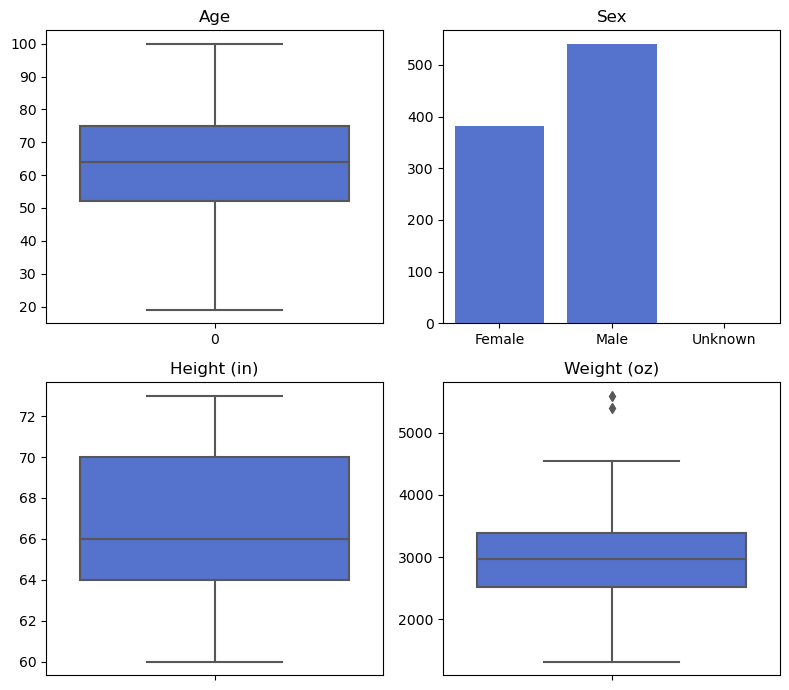

In [58]:
fig, axs = plt.subplots(2, 2, figsize=(8, 7))
sns.boxplot(myPredictorsDf['age'], ax=axs[0][0], color='royalblue')
axs[0][0].set_title('Age')
sns.countplot(x='gender', data=myPredictorsDf, ax=axs[0][1], color='royalblue')
axs[0][1].set_title('Sex')
axs[0][1].set_xlabel('')
axs[0][1].set_ylabel('')
sns.boxplot(y='flo_first_height', data=myPredictorsDf1, ax=axs[1][0], color='royalblue')
axs[1][0].set_title('Height (in)')
axs[1][0].set_xlabel('')
axs[1][0].set_ylabel('')
sns.boxplot(y='flo_first_weight/scale', data=myPredictorsDf1, ax=axs[1][1], color='royalblue')
axs[1][1].set_title('Weight (oz)')
axs[1][1].set_xlabel('')
axs[1][1].set_ylabel('')
plt.tight_layout()
plt.show()

In [84]:
myPredictorsDf['gender'] = (myPredictorsDf['gender'] == 'Male').astype(int)

,pat_enc_csn_id,gender,dx_name,age,death_at_disch
0,1.429376e+09,0,Cardiac arrest,41,0
1,1.067280e+09,1,Cardiac arrest,54,0
2,1.281219e+09,1,Cardiac arrest,56,1
3,1.298698e+09,0,Cardiac arrest,29,0
4,1.305698e+09,1,Cardiac arrest,65,1


#### First and last GCS

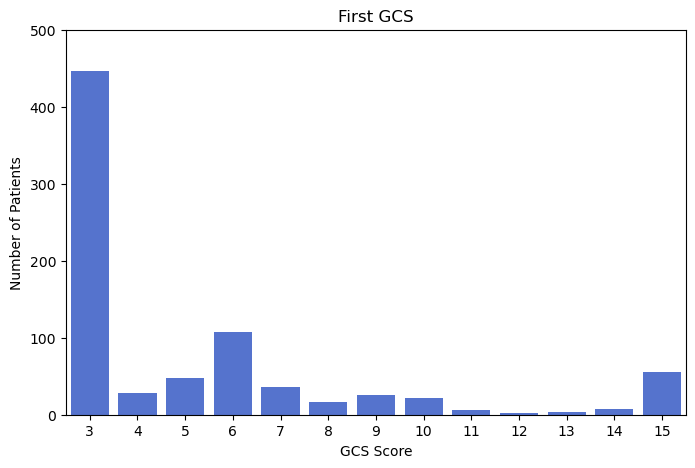

In [71]:
countsMin = myGcsDfMin['meas_value'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
sns.barplot(x=countsMin.index, y=countsMin.values, color='royalblue')
plt.xlabel('GCS Score')
plt.ylabel('Number of Patients')
plt.title('First GCS')
plt.xticks(rotation=0)
plt.ylim((0,500))
plt.show()

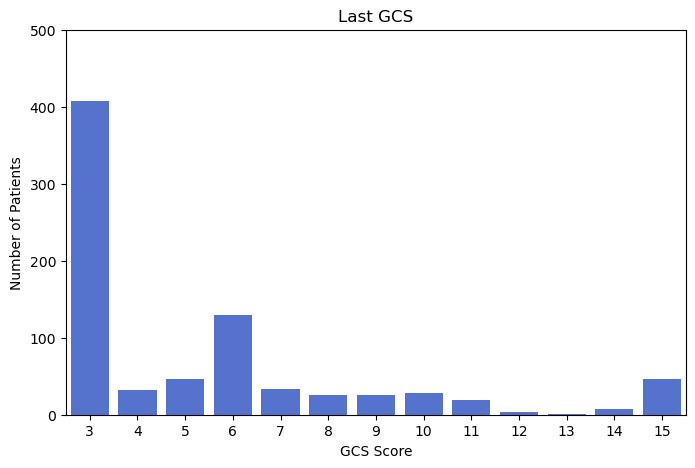

In [72]:
countsMax = myGcsDfMax['meas_value'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
sns.barplot(x=countsMax.index, y=countsMax.values, color='royalblue')
plt.xlabel('GCS Score')
plt.ylabel('Number of Patients')
plt.title('Last GCS')
plt.xticks(rotation=0)
plt.ylim((0,500))
plt.show()

In [ ]:
def getFeaturesFromDf(aDf, aTimeColumn, aTypeColumn, aValueColumn):
    aDf['num_values'] = pd.to_numeric(aDf[aValueColumn], errors='coerce')
    myMasterGroupDf = aDf[(aDf[aTimeColumn] < myHours)].groupby(['pat_enc_csn_id', aTypeColumn])
    myMasterGroupBegin = aDf.loc[myMasterGroupDf[aTimeColumn].idxmin()]
    myMasterGroupEnd = aDf.loc[myMasterGroupDf[aTimeColumn].idxmax()]
    myMasterGroupAgg = myMasterGroupDf.agg({'mean', 'min', 'max'})
    myMasterGroupAgg = myMasterGroupAgg.num_values.reset_index()
    return myMasterGroupDf, myMasterGroupBegin, myMasterGroupEnd, myMasterGroupAgg

In [ ]:
def mergeFeaturesInDf(aDfToMerge, aBegin, aEnd, aAgg, aPrefix, aTypeColumn, aValueColumn):
    print('Running Begin Columns')
    total = int(aBegin[aTypeColumn].nunique() / 10)
    myPredictorsDf1 = aDfToMerge
    i = 0
    print('progress: ', end="")
    for value in aBegin[aTypeColumn].unique():
        myDf = aBegin[aBegin[aTypeColumn] == value]
        myPredictorsDf1 = myPredictorsDf1.merge(myDf[['pat_enc_csn_id', aValueColumn]], on='pat_enc_csn_id', how='left')
        myPredictorsDf1[aPrefix + '_first_' + value] = myPredictorsDf1[aValueColumn]
        myPredictorsDf1.drop(columns=[aValueColumn], inplace=True)
        if (i % total == 0):
            print('#', end="")
        i+= 1
    print()
    print('Running End Columns')
    total = int(aEnd[aTypeColumn].nunique() / 10)
    i = 0
    print('progress: ', end="")
    for value in aEnd[aTypeColumn].unique():
        myDf = aEnd[aEnd[aTypeColumn] == value]
        myPredictorsDf1 = myPredictorsDf1.merge(myDf[['pat_enc_csn_id', aValueColumn]], on='pat_enc_csn_id', how='left')
        myPredictorsDf1[aPrefix + '_last_' + value] = myPredictorsDf1[aValueColumn]
        myPredictorsDf1.drop(columns=[aValueColumn], inplace=True)
        if (i % total == 0):
            print('#', end="")
        i+= 1
    print()
    print('Running Agg Columns')
    total = int(aEnd[aTypeColumn].nunique() / 10)
    i = 0
    print('progress: ', end="")
    for value in aAgg[aTypeColumn].unique():
        myDf = aAgg[aAgg[aTypeColumn] == value]
        myPredictorsDf1 = myPredictorsDf1.merge(myDf[['pat_enc_csn_id', 'max', 'min', 'mean']], on='pat_enc_csn_id', how='left')
        myPredictorsDf1[aPrefix + '_max_' + value] = myPredictorsDf1['max']
        myPredictorsDf1[aPrefix + '_min_' + value] = myPredictorsDf1['min']
        myPredictorsDf1[aPrefix + '_mean_' + value] = myPredictorsDf1['mean']
        myPredictorsDf1.drop(columns=['max', 'min', 'mean'], inplace=True)
        if (i % total == 0):
            print('#', end="")
        i+= 1
    return myPredictorsDf1

In [ ]:
myMasterGroupDf, myMasterGroupBegin, myMasterGroupEnd, myMasterGroupAgg = getFeaturesFromDf(nurse_charting_df, 'nursingchartoffset', 'nursingchartcelltypevalname', 'nursingchartvalue')

In [ ]:
myPredictorsDf1 = mergeFeaturesInDf(myPredictorsDf, myMasterGroupBegin, myMasterGroupEnd, myMasterGroupAgg, 'nurse', 'nursingchartcelltypevalname', 'nursingchartvalue')

In [ ]:
print(list(myPredictorsDf.columns))

In [ ]:
myPredictorsDf = myPredictorsDf1

In [ ]:
gcs_df = nurse_charting_df[nurse_charting_df['nursingchartcelltypevalname']=='GCS Total']

In [ ]:
motor_gcs_df = nurse_charting_df[nurse_charting_df.nursingchartcelltypevalname == 'Motor']

In [ ]:
myGcsDf = gcs_df.sort_values(by=['pat_enc_csn_id', "nursingchartoffset"])
myGcsDf['nursingchartoffset2'] = myGcsDf.nursingchartoffset
myGcsDf2 = myGcsDf.groupby('pat_enc_csn_id').agg({'nursingchartoffset':'min', 'nursingchartoffset2': 'max'})
myGcsDfMin = myGcsDf.merge(myGcsDf2, on=['pat_enc_csn_id', 'nursingchartoffset'], how='inner')
myGcsDfMax = myGcsDf.merge(myGcsDf2, on=['pat_enc_csn_id', 'nursingchartoffset2'], how='inner')

In [ ]:
myMGcsDf = motor_gcs_df.sort_values(by=['pat_enc_csn_id', 'nursingchartoffset'])
myMGcsDf['nursingchartoffset2'] = myMGcsDf.nursingchartoffset
myMGcsDf2 = myMGcsDf.groupby('pat_enc_csn_id').agg({'nursingchartoffset':'min', 'nursingchartoffset2': 'max'})
myMGcsDfMin = myMGcsDf.merge(myMGcsDf2, on=['pat_enc_csn_id', 'nursingchartoffset'], how='inner')
myMGcsDfMax = myMGcsDf.merge(myMGcsDf2, on=['pat_enc_csn_id', 'nursingchartoffset2'], how='inner')

In [ ]:
myMGcsDfMax

In [ ]:
myPredictorsDf = myPredictorsDf.merge(myGcsDfMin[['pat_enc_csn_id', 'nursingchartentryoffset', 'nursingchartvalue']], on='pat_enc_csn_id')
myPredictorsDf.rename(columns={'nursingchartentryoffset': 'FirstGCSTime', 'nursingchartvalue': 'FirstGCS'}, inplace=True)
myPredictorsDf =myPredictorsDf.merge(myGcsDfMax[['pat_enc_csn_id', 'nursingchartentryoffset', 'nursingchartvalue']], on='pat_enc_csn_id')
myPredictorsDf.rename(columns={'nursingchartentryoffset': 'LastGCSTime', 'nursingchartvalue': 'LastGCS'}, inplace=True)

In [ ]:
myPredictorsDf = myPredictorsDf.merge(myMGcsDfMin[['pat_enc_csn_id', 'nursingchartentryoffset', 'nursingchartvalue']], on='pat_enc_csn_id', how='outer')
myPredictorsDf.rename(columns={'nursingchartentryoffset': 'FirstMGCSTime', 'nursingchartvalue': 'FirstMGCS'}, inplace=True)
myPredictorsDf =myPredictorsDf.merge(myMGcsDfMax[['pat_enc_csn_id', 'nursingchartentryoffset', 'nursingchartvalue']], on='pat_enc_csn_id', how='outer')
myPredictorsDf.rename(columns={'nursingchartentryoffset': 'LastMGCSTime', 'nursingchartvalue': 'LastMGCS'}, inplace=True)